In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool

In [2]:

# Load dataset (change path if needed)
'''from sklearn.datasets import fetch_kddcup99
data = fetch_kddcup99(subset='SA', percent10=True, as_frame=True)
df = data.frame.copy()'''

# Step 1: Load the dataset (replace with correct path)
# KDD Cup 1999 dataset is available from various sources, including the UCI ML Repository.
# Assuming the dataset is loaded into 'data' DataFrame
df = pd.read_csv("kddcup.data", header=None)

# Step 2: Preprocess the dataset
# Assuming that last column is the target, and that categorical features need encoding
column_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 
                'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 
                'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 
                'num_outbound_cmds', 'is_hot_login', 'is_guest_login', 'count', 'srv_count', 
                'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 
                'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
                'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
                'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
                'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']

df.columns = column_names

In [3]:

# Prepare data
X = df.drop(columns='label')
y = df['label']

# Encode categorical features
cat_features = X.select_dtypes(include='object').columns
for col in cat_features:
    X[col] = LabelEncoder().fit_transform(X[col])

# Encode target
y_encoded = LabelEncoder().fit_transform(y)
class_names = np.unique(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# First: Train-Test Split (stratified)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.1, random_state=42, stratify=y_encoded
)

# Second: Train-Validation Split (NOT stratified due to rare classes)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=1/3, random_state=42
)


In [5]:
# Train CatBoost model
model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    verbose=False
)
model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)

# Predictions
y_pred = model.predict(X_test).flatten()
y_proba = model.predict_proba(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)



Accuracy: 0.9999122169507026
Precision: 0.9998999618221361
Recall: 0.9999122169507026
F1 Score: 0.999905686314995


<Figure size 2000x1000 with 0 Axes>

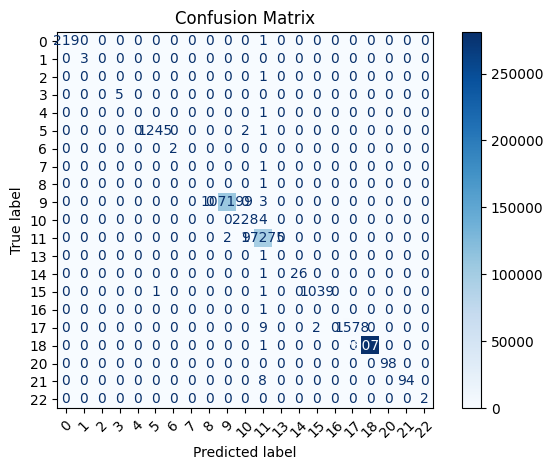

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Set larger figure size
plt.figure(figsize=(20, 10))  # Adjust size here

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(xticks_rotation=45, cmap='Blues', colorbar=True)  # You can customize colors here too

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

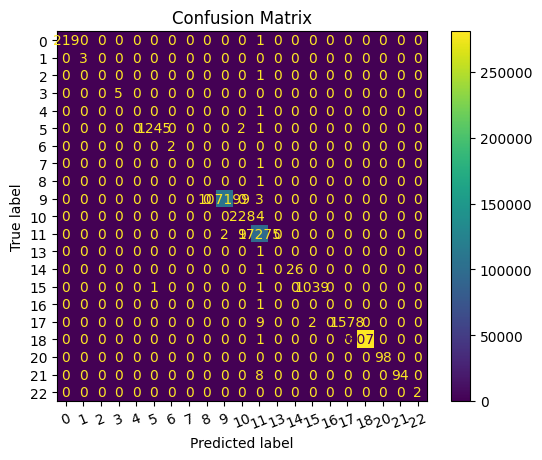

In [11]:
# Confusion Matrix
plt.figure(figsize=(15,10))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(xticks_rotation=22)
plt.title("Confusion Matrix")
plt.show()




c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


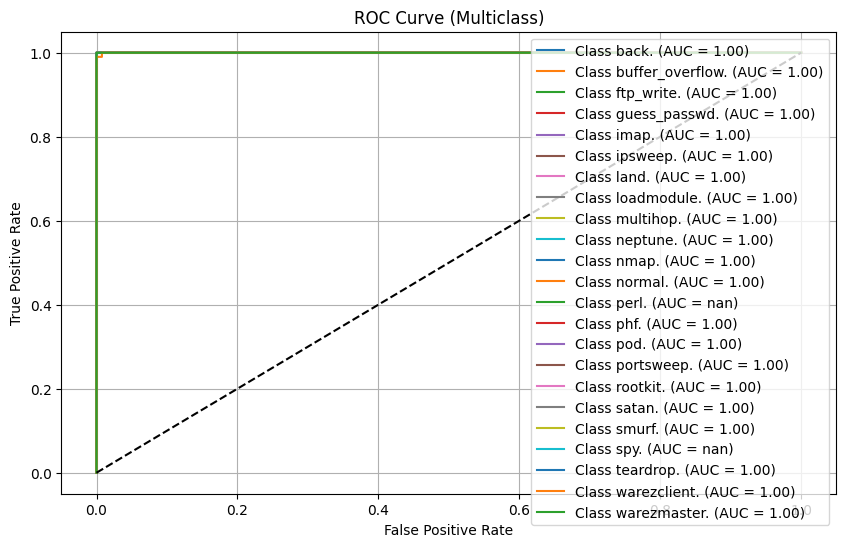

In [8]:
# ROC Curve and AUC (multiclass)
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 6))
for i in range(len(class_names)):
    plt.plot(fpr[i], tpr[i], label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve (Multiclass)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='best')
plt.grid()
plt.show()



c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\user4\Anaconda3\envs\vivek\lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


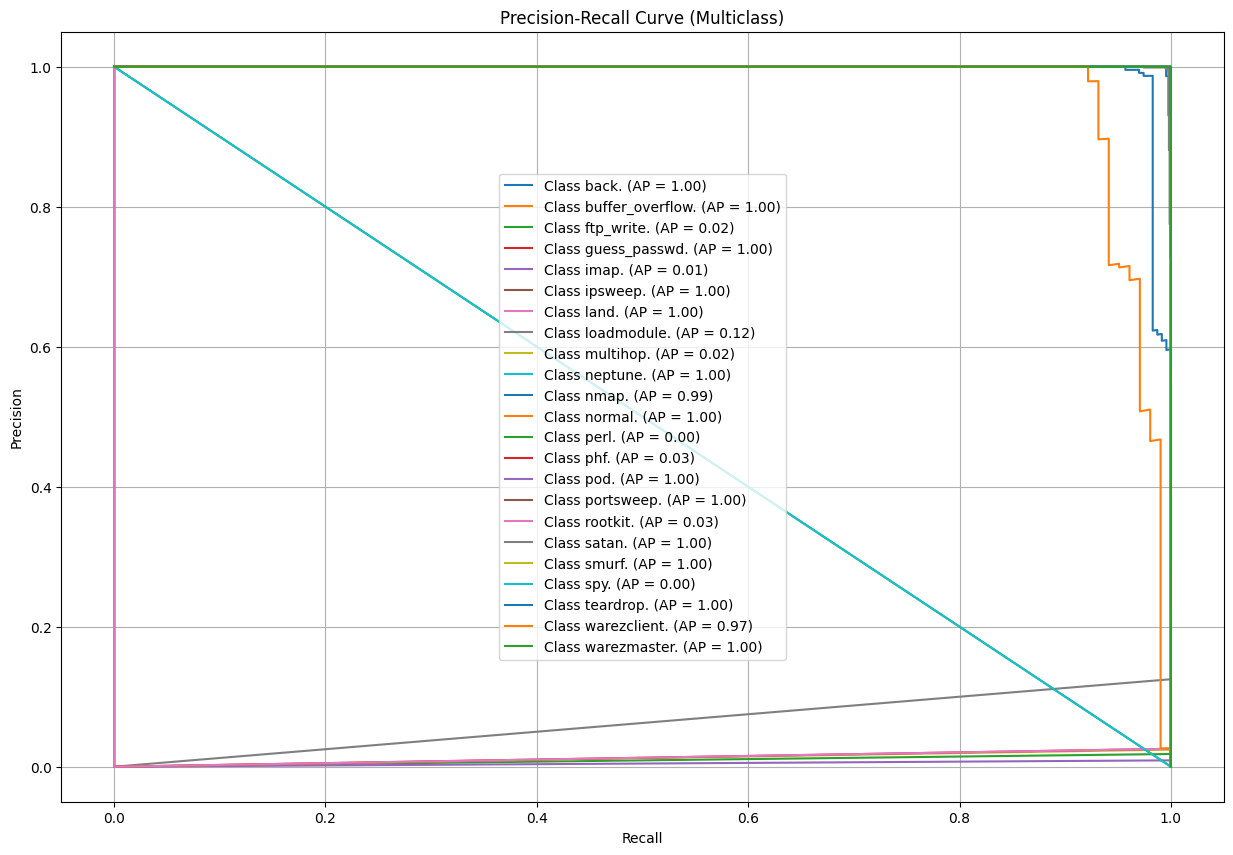

In [9]:
# Precision-Recall Curve (multiclass)
precision_dict = {}
recall_dict = {}
average_precision = {}

plt.figure(figsize=(15, 10))
for i in range(len(class_names)):
    precision_dict[i], recall_dict[i], _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(recall_dict[i], precision_dict[i],
             label=f'Class {class_names[i]} (AP = {average_precision[i]:.2f})')

plt.title("Precision-Recall Curve (Multiclass)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='best')
plt.grid()
plt.show()